# Jedno drzewo decyzyjne

Ideą metod zespołowych jest uzyskanie silnego predyktora z dużej liczby słabych predyktorów. Można to porównać do panelu ekspertów, którzy w drodze głosowania decydują, jak zaklasyfikować nową obserwację. Zbiorowa wiedza jest dokładniejsza niż wiedza pojedynczego eksperta.

Zaczynamy od klasyfikatora drzewa decyzyjnego, który jest słabym predyktorem. Następnie stosując kilka metod skonstruujemy silne klasyfikatory, z których każdy wykorzystuje wiele drzew decyzyjnych.

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree

Loading Pima Indian Diabetes Database https://www.kaggle.com/uciml/pima-indians-diabetes-database

In [77]:
df = pd.read_csv('diabetes.csv')

* Pregnancies - Number of times pregnant,
* Glucose - Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* BloodPressure - Diastolic blood pressure (mm Hg)
* SkinThickness - Triceps skin fold thickness (mm)
* Insulin - 2-Hour serum insulin (mu U/ml)
* BMI - Body mass index
* DiabetesPedigreeFunction - Diabetes pedigree function
* Outcome - 1 means diabetes patient

In [78]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [79]:
df.shape

(768, 9)

### Podział na zmienne niezależne i zmienną zależną oraz podział na zbiór treningowy i testowy

In [80]:
X = df.drop(columns='Outcome')
y = df['Outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Metodą CV znadźmy najlepszy model. Metryką do oceny modelu niech będzie 'recall'. Interesuje nas model, które najlepiej identyfikuje przypadki cukrzycy.

`recall`$=\frac{TP}{TP+FN}$ -  ocenia zdolność klasyfikatora do indetyfikowania próbek oznaczonych etykietą 1 (*positive samples*). Tutaj *pozytywny* oznacza chory na cukrzycę.

In [81]:
from sklearn.model_selection import GridSearchCV

classtree = tree.DecisionTreeClassifier()

param_grid = {'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(5,20)
              }
classtree_gscv = GridSearchCV(classtree, param_grid, scoring='recall', cv=5)
classtree_gscv.fit(X, y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
                         'min_samples_leaf': range(5, 20)},
             scoring='recall')

In [82]:
classtree_gscv.best_estimator_

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5)

In [83]:
classtree_gscv.best_score_

0.6796645702306079

## Trenowanie drzewa na najlepszych parametrach

In [84]:
from sklearn import tree

clftree = tree.DecisionTreeClassifier(max_depth=4, min_samples_leaf=5)
clftree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5)

Drzewo decyzyjne to algorytmem uczenia maszynowego łatwym do zilustrowania i interpretacji (zobaczysz wykres drzewa decyzyjnego poniżej). 

Feature importance (znaczenie zmiennych) to kolejny element wyjaśniania zbudowanego modelu drzewa decyzyjnego.

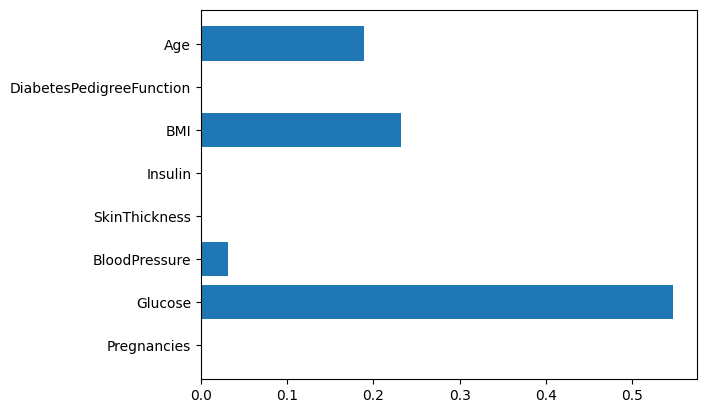

In [85]:
import matplotlib.pyplot as plt
names = X.columns
feature_importances = clftree.feature_importances_
plt.barh(names, feature_importances)
plt.show()

Predykcja przy użyciu wytrenowanego modelu.

In [86]:
y_train_pred = clftree.predict(X_train)
y_test_pred = clftree.predict(X_test)

## Ocena modelu

TP = True positive; FP = False positive; TN = True negative; FN = False negative

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

confusion matrix = 

[TN,  FP]

[FN,  TP]

Macierz pomyłek na zbiorze treningowym

In [88]:
confusion_matrix(y_train,y_train_pred)

array([[336,  57],
       [ 79, 142]], dtype=int64)

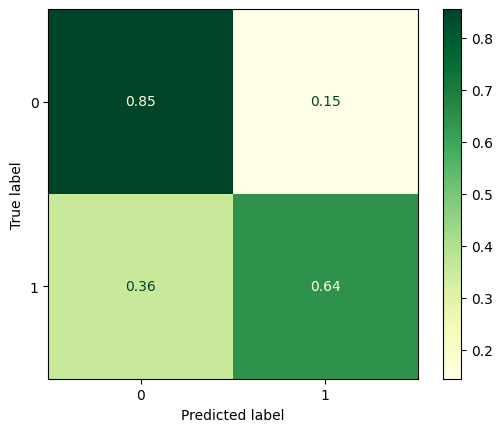

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree, X_train, y_train, cmap='YlGn', normalize = 'true')
plt.show()

Macierz pomyłek na zbiorze testowym

In [90]:
confusion_matrix(y_test,y_test_pred)

array([[91, 16],
       [20, 27]], dtype=int64)

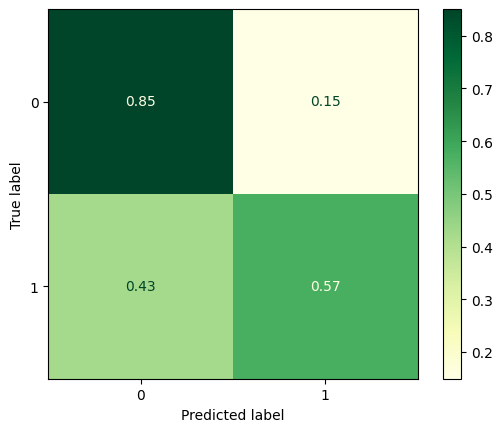

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(clftree, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

Accuracy = (TP + TN)/(TP + TN + FP + FN)

In [92]:
accuracy_score(y_test,y_test_pred)

0.7662337662337663

`recall`$=\frac{TP}{TP+FN}$ -  ocenia zdolność klasyfikatora do indetyfikowania próbek oznaczonych etykietą 1 (*positive samples*).

In [93]:
recall_score(y_test,y_test_pred)

0.574468085106383

Rysowanie drzewa decyzyjnego

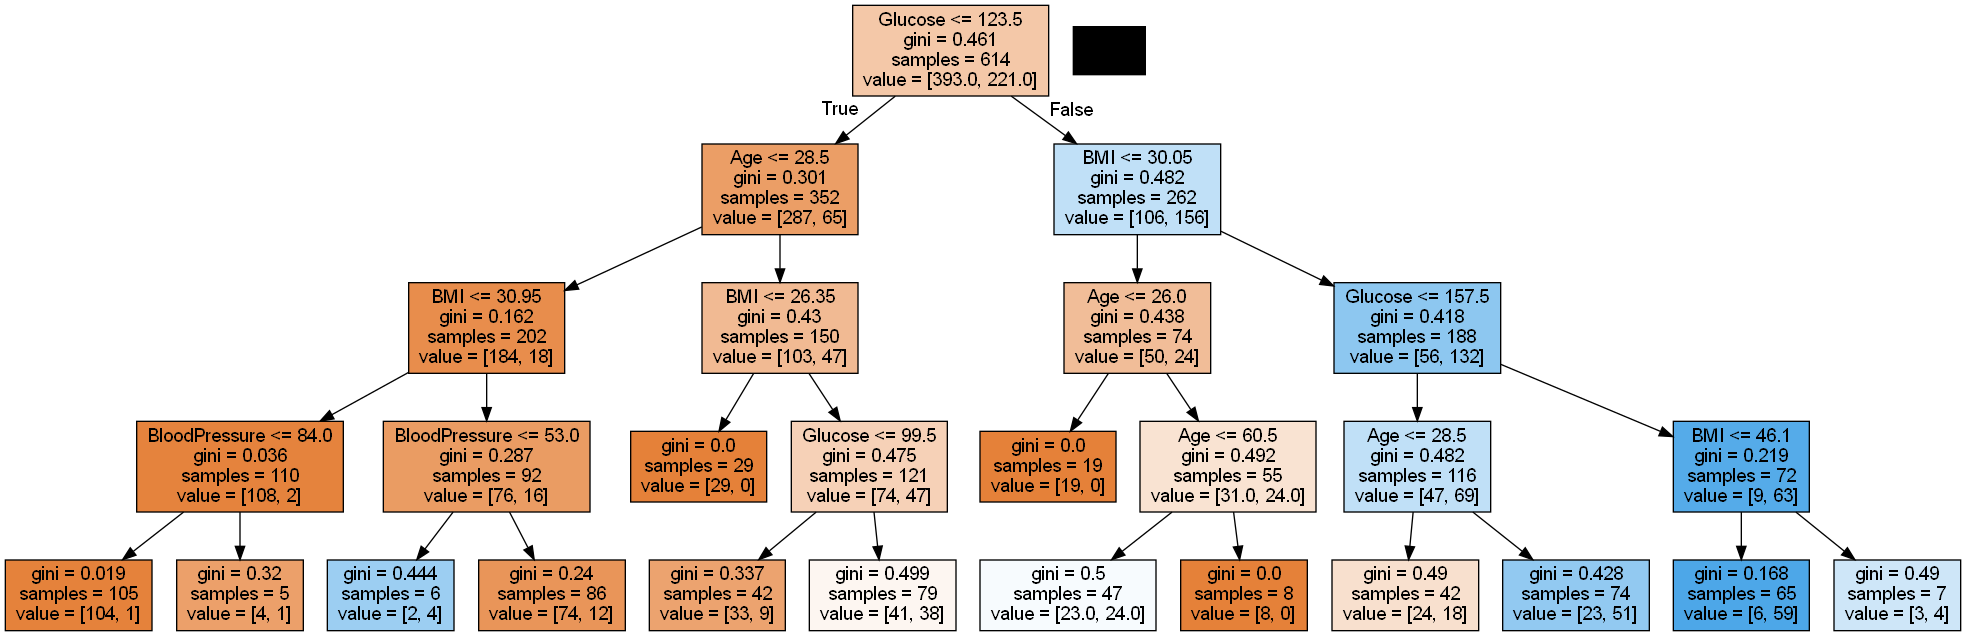

In [94]:
dot_data = tree.export_graphviz(clftree, feature_names=X_train.columns, out_file=None, filled=True)
from IPython.display import Image
import pydotplus
import graphviz
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

# Bagging 

Bagging jest jedną z tzw. metod **zespołowych** tworzenia klasyfikatorów - czyli klasą metod, która agreguje wiele słabych klasyfikatorów w jeden silny klasyfikator.

Bagging — agregacja bootstrap to procedura ogólnego przeznaczenia służąca do zmniejszania wariancji modelu. Pojedyncze drzewo rośnie głęboko i nadmiernie dopasowuje się do zbioru danych. Ale jeśli połączymy wiele tych przewidywań, zmniejszy to nadmierne dopasowanie.

Przykład losowania (próbkowania) ze zwracaniem:

[1,2,3,4,5,6,7] --> [1,2,2,7,4,2,4]  

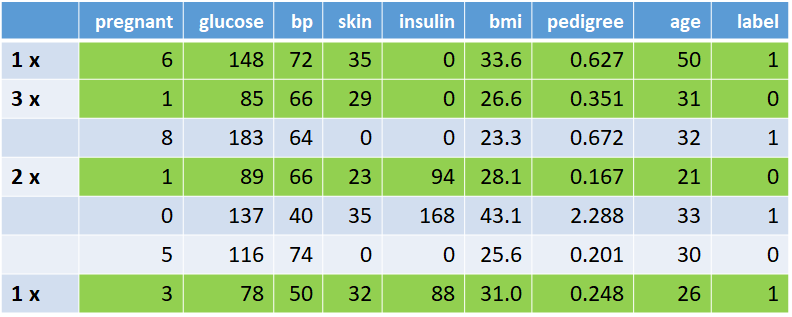

zielone wierszy - dane 'in-the-bag' 

pozostałe wiersze - dane 'out-of-bag'

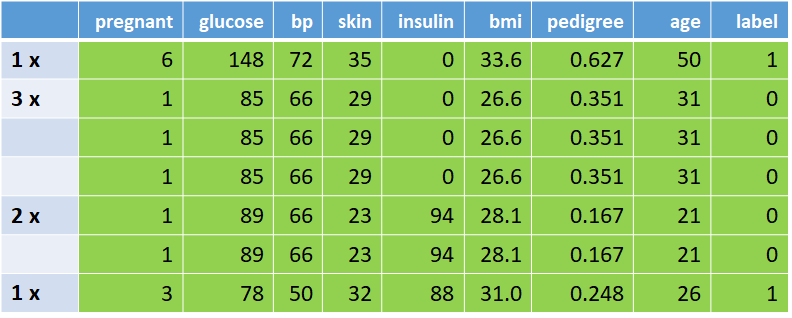

Bagging w 4 krokach:
* wybierz liczbę $B$ modeli do stworzenia modelu zespołowego
* losując ze zwracaniem, wygeneruj $B$ zbiorów danych o tym samym rozmiarze, co dane wejściowe 
* wytrenuj model na każdym z $B$ zbiorów
* uzyskaj prognozę zespołową, agregując wszystkie indywidualne prognozy - głosowanie większościowe (**majority vote**) jest najczęstszą metodą klasyfikacji


https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

In [95]:
from sklearn.ensemble import BaggingClassifier

# jeśli base_estimator=None, to estimator = 'DecisionTreeClassifier'
bagging = BaggingClassifier(estimator=None, n_estimators=100, max_features=1.0,
                            bootstrap=True, bootstrap_features=False,
                            random_state=None, n_jobs=-1, oob_score=True)

bagging.fit(X_train, y_train)

BaggingClassifier(n_estimators=100, n_jobs=-1, oob_score=True)

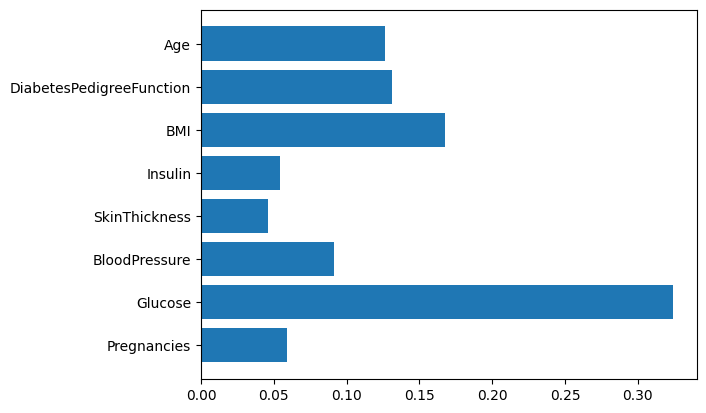

In [96]:
import matplotlib.pyplot as plt
names = X.columns
feature_importances = np.mean([tree.feature_importances_ for tree in bagging.estimators_], axis=0)
plt.barh(names, feature_importances)
plt.show()



In [97]:
y_test_pred = bagging.predict(X_test)

In [98]:
accuracy_score(y_test,y_test_pred)

0.7987012987012987

Można to również obliczyć bezpośrednio za pomocą instancji *bagging* klasy BagginClassifier

In [99]:
bagging.score(X_test,y_test)

0.7987012987012987

In [100]:
recall_score(y_test,y_test_pred)

0.7021276595744681

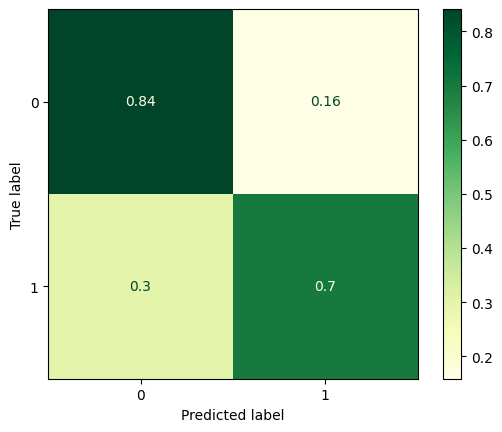

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(bagging, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

### Uwaga
**BaggingClassifier** w sklearn zawiera w sobie kilka znanych klas metod zespołowych. **Pasting** - modele są budowane na losowych podzbiorach (losowanie bez zwracania). **Bagging** - modele są budowane na podzbiorach wielkości całego zbioru danych wylosowanego ze zwracaniem. **Random Subspaces** - model jest budowany na losowym zbiorze zmiennych - losujemy kolumny zamiast wierszy. **Random Patches** - modele są budowane na losowych podzbiorach (losowanie bez zwracania) przy losowym doborze zmiennych. 
* Pasting: **bootstrap=False** (losowanie bez zwracania), **max_feature =1.0** (100% kolumn użytych), **max_samples** mniej niż 1.0 (mniej niż 100% wierszy użytych)
* Bagging: **bootstrap=True** (losowanie ze zwracaniem), **max_feature =1.0** (100% kolumn użytych), **max_samples=1.0** (100% wierszy jest użytych) 
* Random Subspace: **bootstrap=False** (losowanie bez zwracania), **max_feature** mniej niż 1.0 (mniej niż 100% kolumn użytych), **max_samples=1.0** (100% wierszy jest użytych)
* Random Patches: **bootstrap=False** (losowanie bez zwracania), **max_feature** mniej niż 1.0 (mniej niż 100% kolumn użytych), **max_samples** mniej niż 1.0 (mniej niż 100% wierszy użytych)

Później opowiemy o lesie losowym. Użyty model to drzewo decyzyjne. Wiersze są losowane ze zwracaniem **bootstrap=True** dolosowuje się tyle samo wierszy - **max_samples=1.0** - oraz kolumny są dobrane losowo - **max_feature** mniej niż 1.0. To daje nową kombinację losowości.

### What is OOB score?

Policzmy accuracy

In [102]:
accuracy_score(y_test,y_test_pred)

0.7987012987012987

i porównajmy to z **out-of-bag score**.

In [103]:
bagging.oob_score_

0.749185667752443

**1 - oob_score** to tzw. OOB error. Wykazano, że OOB error jest większy niż błąd CV. To oznacza, że oob_score jest istotnie mniejszy niż accuracy score.

https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0201904

Aby wyliczyć OOB score używa się danych out-of-bag jako zbioru testowego. Dla ustalonego wiersza w zbiorze danych: 
1. Znajdź wszystkie modele (np. drzewa), do których wytrenowania nie był użyty ten wiersz. Innymi słowy, znajdź modele, dla których wybrany wiersz należy do ich out-of-bag.
2. Używając tych modeli, metodą głosowania, ustal predykcję dla tego wiersza.
3. Porównaj predykcję z wartością prawdziwą. 
4. Wylicz accuracy dla wartości z punktów 2. i 3.

Obliczanie wyniku OOB (lub błędu OOB) można porównać do k-krotnej walidacji krzyżowej. Wynik OOB jest obliczany podczas budowania modelu. Tak więc k-krotne CV jest k-krotnie droższe obliczeniowo niż obliczenie wyniku OOB.

W tym celu możemy dopasować BaggingClassifier do całego zbioru danych i traktować wynik OOB jak wynik walidacji krzyżowej (dla pojedyńczego zbioru parametrów modelu bazowego).

In [104]:
# 1. Import the estimator object (model)
from sklearn.ensemble import BaggingClassifier

# 2. Create an instance of the estimator
# if base_estimator=None, then the base estimator is a DecisionTreeClassifier.
bagging_all = BaggingClassifier(estimator=None, n_estimators=100, max_features=1.0,
                            bootstrap=True, bootstrap_features=False,
                            random_state=None, n_jobs=-1, oob_score=True)

# 3. Use the trainning data to train the estimator
bagging_all.fit(X, y)

BaggingClassifier(n_estimators=100, n_jobs=-1, oob_score=True)

In [105]:
bagging_all.oob_score_

0.7604166666666666

Przy odrobinie wysiłku można obliczyć inne metryki przy użyciu OBB. Nie będę tu wchodził w szczegóły.

In [106]:
y_all_obb = np.argmax(bagging_all.oob_decision_function_,axis=1)

In [107]:
accuracy_score(y,y_all_obb)

0.7604166666666666

In [108]:
recall_score(y,y_all_obb)

0.6380597014925373

### Bootstrapping do znajdowania przedziałów ufności dla prametrów rozkładów

In [109]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

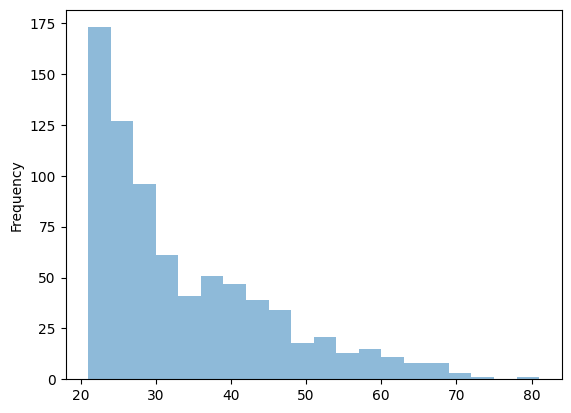

In [110]:
df['Age'].plot.hist(bins=20, alpha=0.5)
plt.show()

In [111]:
print('średnia wieku: '+str(round(df['Age'].mean(),1))+ 
      ', odchylenie standardowe wieku: '+str(round(df['Age'].std(),1)))

średnia wieku: 33.2, odchylenie standardowe wieku: 11.8


In [112]:
# https://scikit-learn.org/stable/modules/generated/sklearn.utils.resample.html
from sklearn.utils import resample

values = df['Age']
# liczba losowań w metodzie bootstrap
n_iterations = 1000

# bootstrap
stats_mean = []
stats_sd = []
for i in range(n_iterations):
    # tworzenie zbioru treningowego 
    # nie używamy funkcji train_test_split, bo chcemy próbę z powtorzeniami
    train = resample(values, n_samples=None)
    mean = train.mean()
    std = train.std()  
    stats_mean.append(mean)
    stats_sd.append(std)

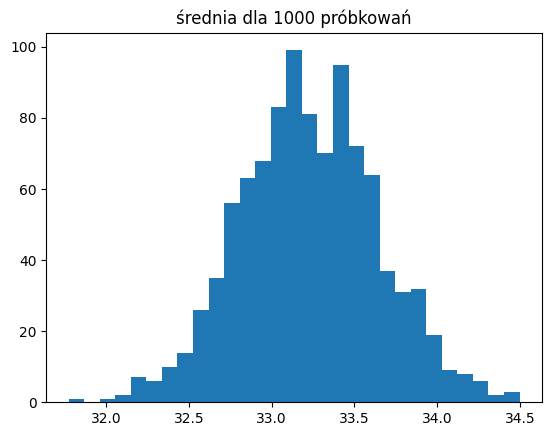

In [113]:
HIST_BINS = np.linspace(min(stats_mean), max(stats_mean), 30)
plt.hist(stats_mean, HIST_BINS)
plt.title('średnia dla 1000 próbkowań')
plt.show()

In [114]:
alpha = 0.95
p = ((1.0-alpha)/2.0) * 100
lower = np.percentile(stats_mean, p)
p = (alpha+((1.0-alpha)/2.0)) * 100
upper = np.percentile(stats_mean, p)
print('%.1f%% przedział ufności dla wartości średniej (%.2f, %.2f)' % (alpha*100, lower, upper))

95.0% przedział ufności dla wartości średniej (32.43, 34.05)


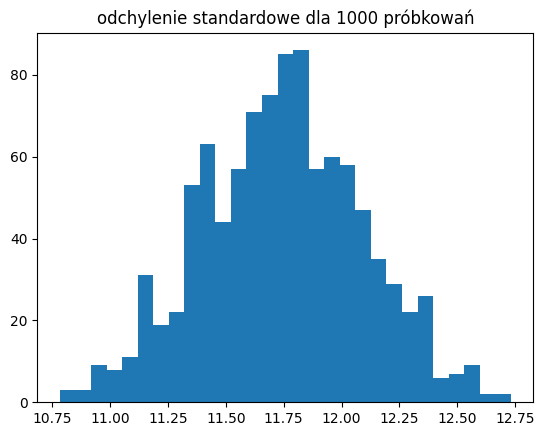

In [115]:
HIST_BINS = np.linspace(min(stats_sd), max(stats_sd), 30)
plt.hist(stats_sd, HIST_BINS)
plt.title('odchylenie standardowe dla 1000 próbkowań')
plt.show()

In [116]:
alpha = 0.95
p = ((1.0-alpha)/2.0) * 100
lower = np.percentile(stats_sd, p)
p = (alpha+((1.0-alpha)/2.0)) * 100
upper = np.percentile(stats_sd, p)
print('%.1f%% przedział ufności dla odchylenia standardowego (%.2f, %.2f)' %
      (alpha*100, lower, upper))

95.0% przedział ufności dla odchylenia standardowego (11.08, 12.40)


### OOB error for finding neccesary number of trees (n_estimators parameter)

*Once the OOB error stabilizes, the training can be
terminated.* T. Hastie, R. Tibshirani and J. Friedman, “Elements of Statistical Learning Ed. 2”

OOB error = 1 - *.oob_score_*

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\ensemble\_bagging.py:769: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\ensemble\_bagging.py:775: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


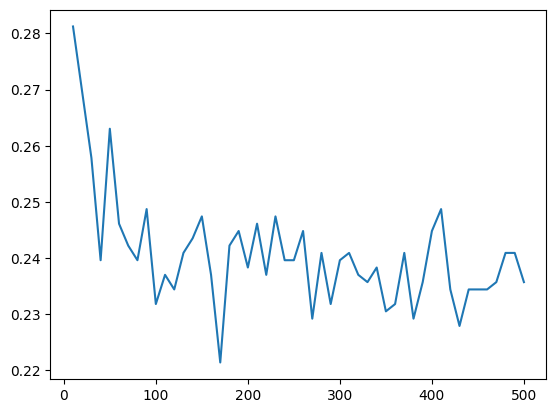

In [117]:
error_rate = []
min_estimators = 10
max_estimators = 500

bagging = BaggingClassifier(estimator=None, bootstrap=True, n_jobs=-1, 
                            oob_score=True, warm_start=False)

for i in range(min_estimators,max_estimators+1, 10):
    bagging.set_params(n_estimators=i)
    bagging.fit(X,y)

    oob_error = 1 - bagging.oob_score_
    error_rate.append(oob_error)

x_axis = range(min_estimators,max_estimators+1, 10)

plt.plot(x_axis, error_rate)
plt.show()

In [118]:
from sklearn.linear_model import LogisticRegression
y = df['Outcome']
x = df.drop(columns = ['Outcome', 'SkinThickness', 'Insulin', 'Age', 'BloodPressure'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 0)

reg_log = LogisticRegression()
reg_log.fit(x_train,y_train)
y_test_pred = reg_log.predict(x_test)
print('accuracy: ',accuracy_score(y_test,y_test_pred))
print('recall: ',recall_score(y_test,y_test_pred))

accuracy:  0.8116883116883117
recall:  0.6170212765957447


In [119]:
y = df['Outcome']
x = df.drop(columns = ['Outcome'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 0)

In [120]:
bagg_log = BaggingClassifier(estimator=LogisticRegression(), n_estimators=1000, max_features=1.0,
                            bootstrap=True, bootstrap_features=False, max_samples=1.0,
                            random_state=1984, n_jobs=-1, oob_score=True)

bagg_log.fit(x_train, y_train)

BaggingClassifier(estimator=LogisticRegression(), n_estimators=1000, n_jobs=-1,
                  oob_score=True, random_state=1984)

In [121]:
y_test_pred = bagg_log.predict(x_test)
print('accuracy: ',accuracy_score(y_test,y_test_pred))
print('recall: ',recall_score(y_test,y_test_pred))

accuracy:  0.8311688311688312
recall:  0.6170212765957447
